In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from main_agent_based import ModelClass
from plots import plot_shares, plot_series
from helper_functions import params_to_latex

model = ModelClass()

par = model.par
sim = model.sim
model.solve(do_print=True)

params_to_latex(par)

Iteration 1: eps = 1.00e+11
Iteration 2: eps = 1.21e+01
Iteration 3: eps = 9.74e+00
Iteration 4: eps = 7.87e+00
Iteration 5: eps = 6.31e+00
Iteration 6: eps = 5.10e+00
Iteration 7: eps = 4.15e+00
Iteration 8: eps = 4.01e+00
Iteration 9: eps = 2.59e+00
Iteration 10: eps = 2.60e+00
Iteration 11: eps = 5.64e+00
Iteration 12: eps = 6.09e+00
Iteration 13: eps = 3.09e+00
Iteration 14: eps = 9.71e-01
Iteration 15: eps = 8.94e-01
Iteration 16: eps = 1.11e+00
Iteration 17: eps = 3.37e+00
Iteration 18: eps = 2.79e+00
Iteration 19: eps = 3.53e-01
Iteration 20: eps = 2.17e+00
Iteration 21: eps = 9.90e-01
Iteration 22: eps = 2.23e+00
Iteration 23: eps = 2.19e+00
Iteration 24: eps = 3.20e-01
Iteration 25: eps = 1.74e+00
Iteration 26: eps = 2.79e+00
Iteration 27: eps = 9.03e-01
Iteration 28: eps = 1.14e+00
Iteration 29: eps = 4.80e-01
Iteration 30: eps = 4.35e-01
Iteration 31: eps = 1.68e+00
Iteration 32: eps = 1.02e-02
Iteration 33: eps = 4.32e-03
Convergence achieved at iteration 33 with eps = 4.32

C:\Users\per.eco\AppData\Local\Temp\ipykernel_20184\4184157916.py:9: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(model.sol.wage[:, :], axis=0), linewidth=2)


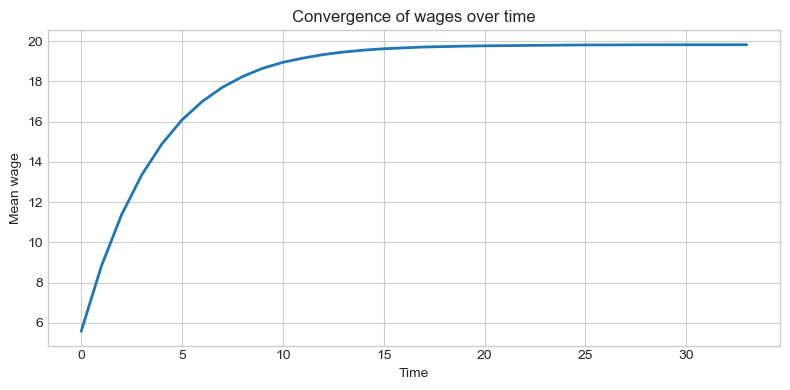

C:\Users\per.eco\AppData\Local\Temp\ipykernel_20184\4184157916.py:18: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(model.sol.l_h, axis=0), linewidth=2)


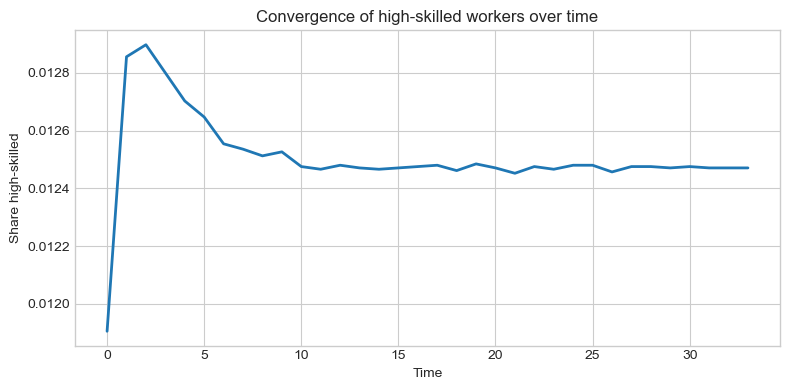

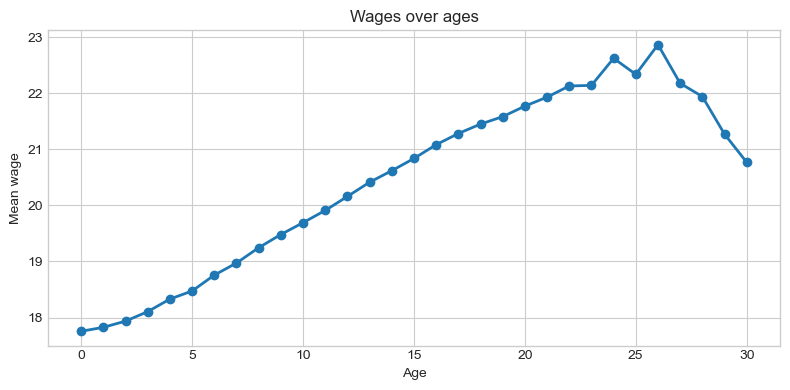

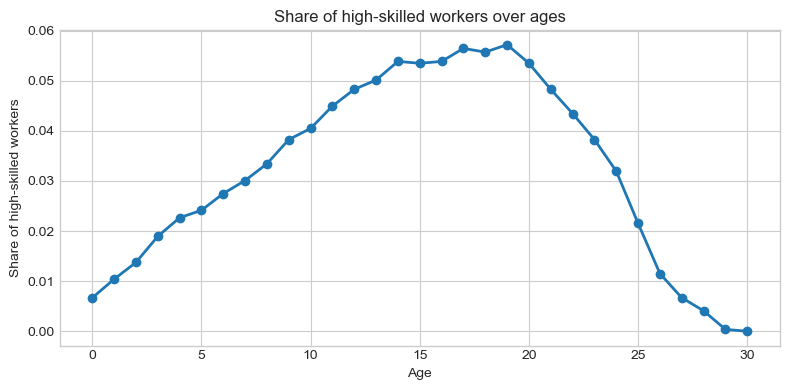

In [2]:
t = np.count_nonzero(~np.isnan(model.sol.age[0,:])) - 1

plt.style.use("seaborn-v0_8-whitegrid")

age_groups = range(model.par.n)

# 1. Convergence of wages over time
plt.figure(figsize=(8, 4))
plt.plot(np.nanmean(model.sol.wage[:, :], axis=0), linewidth=2)
plt.title("Convergence of wages over time")
plt.xlabel("Time")
plt.ylabel("Mean wage")
plt.tight_layout()
plt.show()

# 2. Convergence of high-skilled workers over time
plt.figure(figsize=(8, 4))
plt.plot(np.nanmean(model.sol.l_h, axis=0), linewidth=2)
plt.title("Convergence of high-skilled workers over time")
plt.xlabel("Time")
plt.ylabel("Share high-skilled")
plt.tight_layout()
plt.show()

# 3. Wages over ages
means = [
    np.nanmean(model.sol.wage[:, t][model.sol.age[:, t] == i])
    for i in age_groups
]

plt.figure(figsize=(8, 4))
plt.plot(list(age_groups), means, marker="o", linewidth=2)
plt.title("Wages over ages")
plt.xlabel("Age")
plt.ylabel("Mean wage")
plt.tight_layout()
plt.show()

# 4. Share of high-skilled workers over ages
l_h_mask = model.sol.l_h[:, t] == 1

count = [
    len(model.sol.l_h[l_h_mask, t][model.sol.age[l_h_mask, t] == i])
    for i in age_groups
]

count = np.array(count) / np.sum(count)

plt.figure(figsize=(8, 4))
plt.plot(list(age_groups), count, marker="o", linewidth=2)
plt.title("Share of high-skilled workers over ages")
plt.xlabel("Age")
plt.ylabel("Share of high-skilled workers")
plt.tight_layout()
plt.show()